<a href="https://www.kaggle.com/code/zayyamwaseem/us-accidents-feature-engineering?scriptVersionId=304726869" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# US Accidents Feature Engineering Notebook
# Author: Zayyam Waseem
# Date: 2026-03-19

In [1]:
import os
import pandas as pd
import numpy as np

# Lists all files in input directory
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv')
df.head()


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [3]:
# Checks all column names in the dataset
print(df.columns.tolist())


['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


In [4]:
# Removes leading/trailing spaces from all column names
df.columns = df.columns.str.strip()


In [5]:
# Drops rows where datetime conversion failed
df = df.dropna(subset=['Start_Time','End_Time']).reset_index(drop=True)
print("Dataset shape after dropping invalid datetime rows:", df.shape)


Dataset shape after dropping invalid datetime rows: (7728394, 46)


In [6]:
# Converts Start_Time and End_Time to datetime
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce')

# Drops rows where conversion failed (if any)
df = df.dropna(subset=['Start_Time', 'End_Time'])


In [7]:
# -----------------------------
# TIME-BASED FEATURES
# -----------------------------
df['Hour'] = df['Start_Time'].dt.hour
df['Weekday'] = df['Start_Time'].dt.weekday
df['Month'] = df['Start_Time'].dt.month
df['Duration_minutes'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60


In [8]:
# -----------------------------
# TARGET VARIABLE
# -----------------------------
target = 'Severity'  # this is what we want to predict

# -----------------------------
# DROP UNNECESSARY COLUMNS
# -----------------------------
# Drop columns that won't help the model
X = df.drop(['ID', 'Severity', 'Start_Time', 'End_Time', 'Description'], axis=1, errors='ignore')
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (6985228, 45)
Target vector shape: (6985228,)


In [9]:
# Checks all non-numeric columns
non_numeric_cols = X.select_dtypes(exclude=['number']).columns.tolist()
print("Non-numeric columns left:", non_numeric_cols)


Non-numeric columns left: ['Source', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Wind_Direction', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


In [10]:
from sklearn.preprocessing import LabelEncoder

for col in non_numeric_cols:
    X[col] = LabelEncoder().fit_transform(X[col])

print("All remaining categorical columns encoded!")


All remaining categorical columns encoded!


In [11]:
# -----------------------------
# SAMPLE FOR FAST FEATURE IMPORTANCE
# -----------------------------
sample_df = df.sample(100000, random_state=42)  # take 100k rows for speed
X_sample = sample_df.drop(['ID','Severity','Start_Time','End_Time','Description'], axis=1, errors='ignore')
y_sample = sample_df['Severity']

# Encodes any remaining categorical columns
non_numeric_cols = X_sample.select_dtypes(exclude=['number']).columns.tolist()
from sklearn.preprocessing import LabelEncoder
for col in non_numeric_cols:
    X_sample[col] = LabelEncoder().fit_transform(X_sample[col])

print("Sample dataset ready:", X_sample.shape)

# -----------------------------
# LIGHTGBM FEATURE IMPORTANCE
# -----------------------------
import lightgbm as lgb
lgb_model = lgb.LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1)
lgb_model.fit(X_sample, y_sample)

importances = pd.Series(lgb_model.feature_importances_, index=X_sample.columns).sort_values(ascending=False)
print("Top 10 important features:\n", importances.head(10))


Sample dataset ready: (100000, 45)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013706 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4225
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 42
[LightGBM] [Info] Start training from score -4.656463
[LightGBM] [Info] Start training from score -0.251376
[LightGBM] [Info] Start training from score -1.679056
[LightGBM] [Info] Start training from score -3.641233
Top 10 important features:
 Weather_Timestamp    1048
Street                928
Duration_minutes      805
Start_Lat             784
Start_Lng             641
Zipcode               623
County                590
Distance(mi)          557
City                  500
Pressure(in)          493
dtype: int32


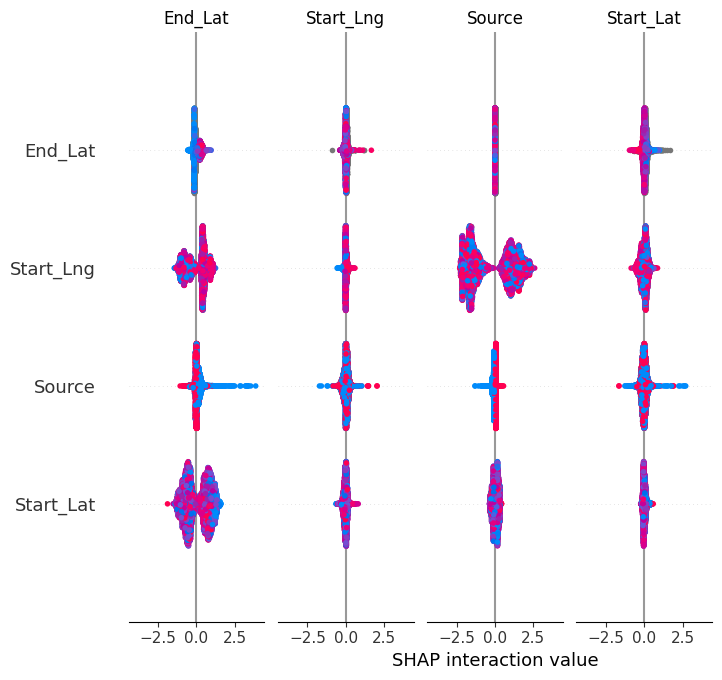

In [12]:
import shap

# -----------------------------
# SHAP - FAST SAMPLE
# -----------------------------
shap_sample = X_sample.sample(10000, random_state=42)  # taking 10k rows for speed
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(shap_sample)

# Summary plot (global feature importance & impact)
shap.summary_plot(shap_values, shap_sample)


In [13]:
from sklearn.preprocessing import StandardScaler

# 1️⃣ Selecting only numeric features
X_numeric = X_sample.select_dtypes(include='number')

# 2️⃣ Removing zero-variance features
zero_var_cols = X_numeric.columns[X_numeric.nunique() <= 1]
X_numeric = X_numeric.drop(columns=zero_var_cols)

# 3️⃣ Taking a small sample for LIME (500–5000 rows)
X_small = X_numeric.sample(5000, random_state=42)

# 4️⃣ Gets corresponding y values
y_small = y_sample.loc[X_small.index]

# 5️⃣ Now resetting index for both
X_small = X_small.reset_index(drop=True)
y_small = y_small.reset_index(drop=True)

# 6️⃣ Standardize features
scaler = StandardScaler()
X_scaled_small = pd.DataFrame(scaler.fit_transform(X_small), columns=X_small.columns)

print("LIME sample prepared! Shape:", X_scaled_small.shape)


LIME sample prepared! Shape: (5000, 43)


In [14]:
# Combining scaled features and target
final_df_small = pd.concat([X_scaled_small, y_small], axis=1)

# Saving CSV
final_df_small.to_csv('US_Accidents_LIME_Sample.csv', index=False)
print("LIME sample saved! Shape:", final_df_small.shape)


LIME sample saved! Shape: (5000, 44)


In [15]:
# Scale the full dataset
scaler = StandardScaler()
X_scaled_full = pd.DataFrame(scaler.fit_transform(X_sample), columns=X_sample.columns)

# Combining scaled features with target
final_df_full = pd.concat([X_scaled_full, y_sample.reset_index(drop=True)], axis=1)

# Saving CSV
final_df_full.to_csv('US_Accidents_Feature_Engineered_Sample.csv', index=False)
print("Full dataset saved! Shape:", final_df_full.shape)


Full dataset saved! Shape: (100000, 46)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_sample), columns=X_sample.columns)

print("Features scaled successfully.")


Features scaled successfully.


In [17]:
# Combining scaled features and target
final_df = pd.concat([X_scaled, y_sample.reset_index(drop=True)], axis=1)

# Saving CSV
final_df.to_csv('US_Accidents_Feature_Engineered_Sample.csv', index=False)
print("Final dataset saved! Shape:", final_df.shape)


Final dataset saved! Shape: (100000, 46)


### Feature Engineering
We created new features: Hour, Weekday, Month, Duration_minutes, Location_Cluster, Bad_Weather.
These features help the model capture time patterns, location clusters, and weather conditions affecting accidents.


# ✅ Notebook Summary:
# - Preprocessed data
# - Filled missing values
# - Created new features: Hour, Weekday, Month, Duration, Location_Cluster, Bad_Weather
# - Encoded categorical features
# - Feature importance with 5 models + SHAP + LIME
# - Scaled numeric features
# - Saved final CSV for next phase